In [1]:
import os,pickle,re

import numpy as np
import pandas as pd
from sklearn.metrics import make_scorer,mean_absolute_error,mean_squared_error
import shap

from project_package.visualization import Model_Visualizer
from project_package import evaluation,modeling

In [2]:
# choose to test either full version or lite version
use_lite_version = False
if use_lite_version:
    base_directory = 'supervised_lite'
else:
    base_directory = 'supervised'

# setting
recalculate_evaluation = False

#### Problem 2: Regression (booking fare prediction)

In [ ]:
# based on the RMSE metric on evaluation set, ridge regression model was chosen.
family_report = pd.read_csv(f'{base_directory}/reg_all_models_metrics_Booking_Value_fill_scaled_report.csv')
family_report

,model,MAE,RMSE,R2,best_params,cv_mean,cv_std
0,ridge,1.005868,1.682957,-0.004740,{'reg__alpha': 100},1.577236,0.043455
1,tree,1.033412,1.702391,-0.028079,"{'reg__max_depth': 3, 'reg__min_samples_leaf':...",1.601062,0.042169
2,knn,1.079013,1.726743,-0.057702,"{'reg__n_neighbors': 15, 'reg__weights': 'unif...",1.653887,0.042256


In [3]:
files = os.listdir(base_directory)

file = [item for item in files if 'Booking Value_fill_scaled.pkl' in item][0]

model_path = os.path.join(base_directory, file)

with open(model_path, "rb") as f:
    model = pickle.load(f)
model

Pipeline(steps=[('pre',
                 ColumnTransformer(sparse_threshold=1.0,
                                   transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000020155832FA0>),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000020155832370>)])),
                ('reg', Ridge(alpha=100))])

Load the train and test data

In [ ]:
split_df = pd.read_csv(os.path.join(base_directory, 'split_assignments_regression_Booking_Value_fill_scaled.csv'))

if use_lite_version:
    model_data =pd.read_csv('datasets/processed/ncr_ride_bookings_with_weather_filled_scaled_short__Booking_Value_fill_scaled__top20_s30.csv')
else:
    model_data =pd.read_csv('datasets/processed/ncr_ride_bookings_with_weather_filled_scaled_short.csv')

In [5]:
# feature_cols = [re.sub(r'^num__', '', name) for name in model[0].get_feature_names_out()]
# feature_cols = [re.sub(r'cat__', '', name) for name in feature_cols]
# get_cols = ['Booking Value_fill_scaled'] + feature_cols

# train data
train_split = split_df.loc[split_df.split=='train'][['Booking ID','Customer ID']]
train_data = model_data.merge(train_split,on=['Booking ID','Customer ID'])
y_train = train_data['Booking Value_fill_scaled']
train_data = modeling.drop_unnecessary_cols(train_data)
train_data['Booking Value_fill_scaled'] = y_train
# validation data
test_split = split_df.loc[split_df.split=='valid'][['Booking ID','Customer ID']]
test_data = model_data.merge(test_split,on=['Booking ID','Customer ID'])
y_test = test_data['Booking Value_fill_scaled']
test_data = modeling.drop_unnecessary_cols(test_data)
test_data['Booking Value_fill_scaled'] = y_test

# train_data = train_data[get_cols]
# test_data = test_data[get_cols]


In [6]:
prediction_df = pd.read_csv(f'{base_directory}/reg_best_Booking_Value_fill_scaled_ridge_preds.csv')

# check model metric score
print('---------on training dataset--------------')
print('MAE from model:',mean_absolute_error(y_train,model.predict(train_data)))
print()
print('MSE from model:',mean_squared_error(y_train,model.predict(train_data)))

print()
print('---------on test dataset--------------')
print('MAE from model:',mean_absolute_error(y_test,model.predict(test_data)))
print('MAE from file:',mean_absolute_error(prediction_df.y_true,prediction_df.y_pred))
print()
print('MSE from model:',mean_squared_error(y_test,model.predict(test_data)))
print('MSE from file:',mean_squared_error(prediction_df.y_true,prediction_df.y_pred))

---------on training dataset--------------
MAE from model: 0.9855812576621764

MSE from model: 2.33670840200232

---------on test dataset--------------
MAE from model: 1.0058680994237605
MAE from file: 1.0058680993974383

MSE from model: 2.832343877590181
MSE from file: 2.832343871133698


In [7]:
# create visualization object

reg_vis_obj = Model_Visualizer(
    train_data,
    test_data,
    y_train,
    y_test,
    # there are so many feature in the ridge model so we skip this
    feature_names = [f'feature_{i}' for i in range(model[0].get_feature_names_out().shape[0])],
    target_name='Booking Value_fill_scaled'
    )

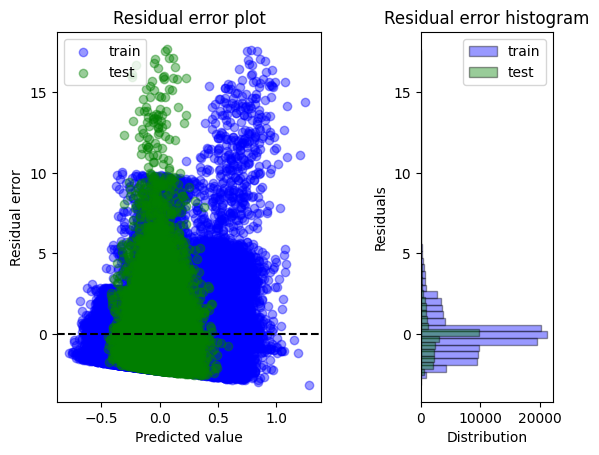

In [8]:
#residue plot 
reg_vis_obj.residual_plot(model,bins=50,alpha=0.4)

Feature Importance and Ablation Analysis

<Axes: title={'center': 'Feature Importance plot'}, xlabel='Importance', ylabel='Features'>

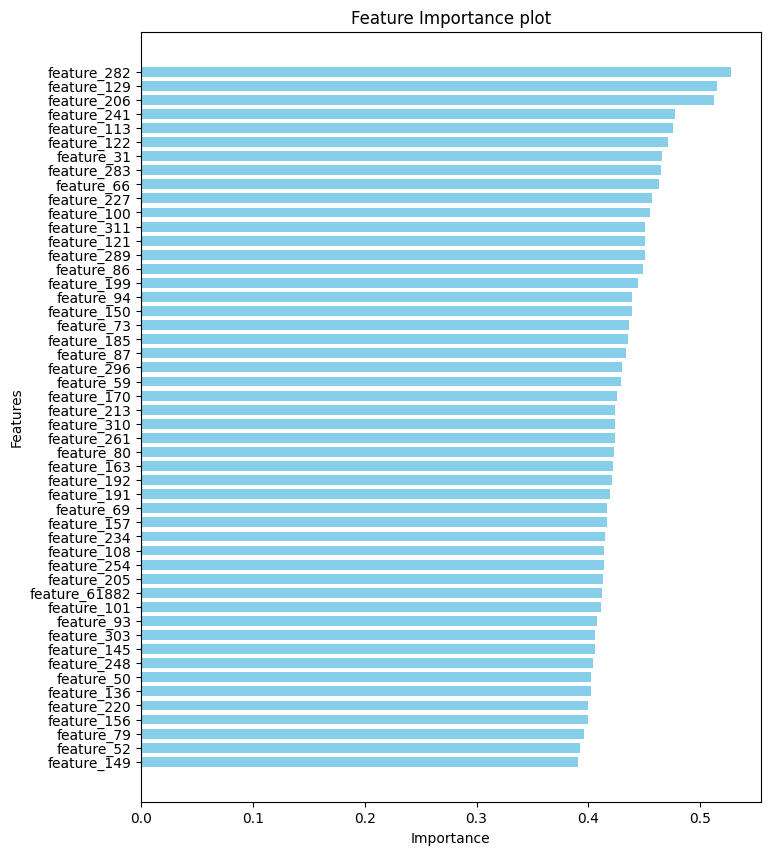

In [9]:
reg_vis_obj.feature_importance_plot(model.named_steps['reg'].coef_,normalize=False,top_n=50,figsize=(8,10))

In [10]:
# try:
#     os.makedirs(f'{base_directory}/evaluation', exist_ok=True)

#     if not recalculate_evaluation:
#         with open(base_directory + "/evaluation/booking_fare_permutation_train_result.pkl", "rb") as f:
#             train_permute = pickle.load(f)
#         with open(base_directory + "/evaluation/booking_fare_permutation_test_result.pkl", "rb") as f:
#             test_permute = pickle.load(f)
#     else:
#         raise Exception('Recalculating permutation test')
# except:
#     train_permute,test_permute = evaluation.permutation_test(
#         model,train_data,test_data,
#         target_col = 'Booking Value_fill_scaled',scorer='neg_mean_absolute_error',random_state=0,n_jobs=-1
#     )

#     with open(base_directory + "/evaluation/booking_fare_permutation_train_result.pkl", "wb") as f:
#         pickle.dump(train_permute, f)

#     with open(base_directory + "/evaluation/booking_fare_permutation_test_result.pkl", "wb") as f:
#         pickle.dump(test_permute, f)

In [11]:
# reg_vis_obj.permutation_importance_plot(train_permute,figsize=(8,6),title='Permutation importance on train data')

In [12]:
# reg_vis_obj.permutation_importance_plot(test_permute,figsize=(8,6),title='Permutation importance on test data')

In [13]:
remove_features = ['wind_speed_10m_dropoff_scaled',
                   'pick_locality',
                   'booking_hour',
                   'Ride Distance_fill_scaled',
                   'apparent_temperature_dropoff_scaled',
                   ['wind_speed_10m_dropoff_scaled','apparent_temperature_dropoff_scaled'],
                   ['pick_latitude','pick_longitude','pick_locality','Pickup Location','pick_address'],
                   ['booking_hour','Ride Distance_fill_scaled']
                    ]

try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)
    if not recalculate_evaluation:
        score_array = np.load(base_directory + '/evaluation/booking_fare_ablation_test.npy')
        eval_df = pd.read_csv(base_directory + '/evaluation/booking_fare_ablation_test.csv')
    else:
        raise Exception('Recalculating ablation test')
except:

    score_array,eval_df = evaluation.ablation_test(
        model,
        train_data = train_data,
        test_data = test_data,
        target_col = 'Booking Value_fill_scaled',
        scorer=make_scorer(mean_absolute_error),
        stratify=False,
        remove_features = remove_features,
        n_jobs=-1
    )

    np.save(base_directory + '/evaluation/booking_fare_ablation_test.npy',score_array)
    eval_df.to_csv(base_directory + '/evaluation/booking_fare_ablation_test.csv',index=False)

eval_df.head()

,remove_features,score_mean,score_std,score_test
0,none,1.009655,0.012316,0.985581
1,wind_speed_10m_dropoff_scaled,1.009655,0.012316,1.005831
2,pick_locality,1.009490,0.012278,1.005638
3,booking_hour,1.007815,0.012364,1.005690
4,Ride Distance_fill_scaled,1.009656,0.012305,1.005850


<Axes: title={'center': 'Booking fare: Ablation test'}, xlabel='mean absolute error'>

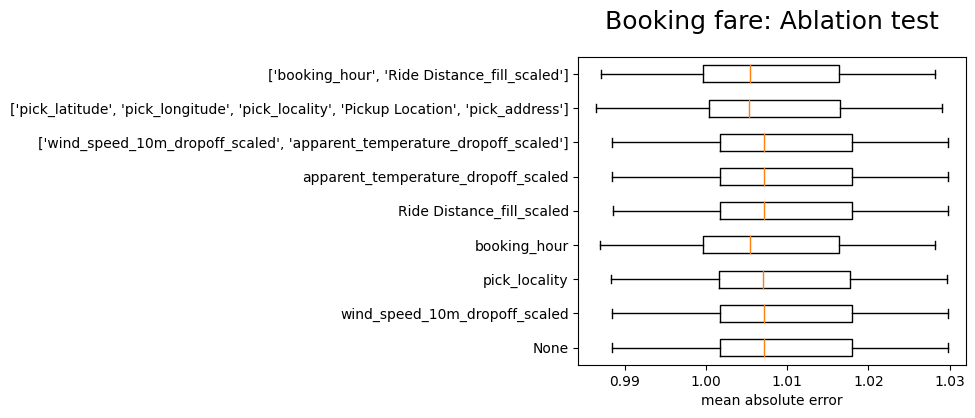

In [23]:
# Ablation test plot
reg_vis_obj.box_plot(score_array.T,labels=['None'] + remove_features,
                     title='Booking fare: Ablation test',
                     figsize = (5, 4),
                     xlabel='mean absolute error')

Sensivity analysis

In [15]:
try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)
    if not recalculate_evaluation:
        eval_df = pd.read_csv(base_directory + '/evaluation/booking_fare_sensivity_test.csv')
    else:
        raise Exception('Recalculating sensivity test')
except:
    grids = {
        'reg__alpha':np.logspace(-3,3,7)
#         'reg__tol':np.logspace(-6,-2,5),
        # 'reg__max_iter':np.linspace(1000,20000,20).astype(int)
    }
    eval_df = evaluation.supervised_sensivity_test(
        model,train_data,
        target_col='Booking Value_fill_scaled',
        param_grid=grids,
        scoring = 'neg_mean_absolute_error',
        verbose=3,
        n_jobs=-1
    )
    eval_df.to_csv(base_directory + '/evaluation/booking_fare_sensivity_test.csv',index=False)
eval_df.head()

,reg__alpha,neg_mean_absolute_error,neg_mean_absolute_error_std
0,0.001,-2.028948,0.039661
1,0.010,-1.572613,0.010663
2,0.100,-1.363796,0.011495
3,1.000,-1.178509,0.011444
4,10.000,-1.052654,0.012005


In [22]:
# plot_1_cond = eval_df.reg__max_iter.unique()[1]
# plot_2_cond = eval_df.reg__alpha.unique()[2]

# reg_vis_obj.sensivity_plot(eval_df,
#                'neg_mean_absolute_error',
#                param1 = ('reg__alpha','reg__max_iter',plot_1_cond),
#                param2 = ('reg__max_iter','reg__alpha',plot_2_cond),
#                subplot_titles = [
#                    f'Sensivity vs. alpha (with max_iter={plot_1_cond})',
#                    f'Sensivity vs. max_iter (with alpha={plot_2_cond})',
#                    None
#                ],
#                log_param1=True
#                )

reg_vis_obj.sensivity_plot(
    eval_df,
    'neg_mean_absolute_error',
    param2 = 'reg__alpha',
    log_param2=True,
    subplot_titles = [
        None,
        'Sensivity vs. alpha',
        None
    ],
)

Learning curve

In [17]:
try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)
    if not recalculate_evaluation:
        result_df = pd.read_csv(base_directory + '/evaluation/booking_fare_learning_curve.csv')
    else:
        raise Exception('Recalculating learning curve')
except:
    _,_,result_df = evaluation.learning_curve_test(
    model,train_data,
    target_col='Booking Value_fill_scaled',
    sample_range=np.logspace(3,5,30).astype(int),
    scorer = make_scorer(mean_absolute_error),
    stratify=False,
    n_jobs=-1,
    random_state=0
    )

    result_df.to_csv(base_directory + '/evaluation/booking_fare_learning_curve.csv',index=False)

result_df.head(5)

,n_sample,score_mean,score_std
0,1000,1.104298,0.168439
1,1172,1.072084,0.157938
2,1373,1.064552,0.127933
3,1610,1.055480,0.107687
4,1887,1.048992,0.086019


<Axes: title={'center': 'Learning curve analysis'}, xlabel='No. of training records', ylabel='mean absolute error'>

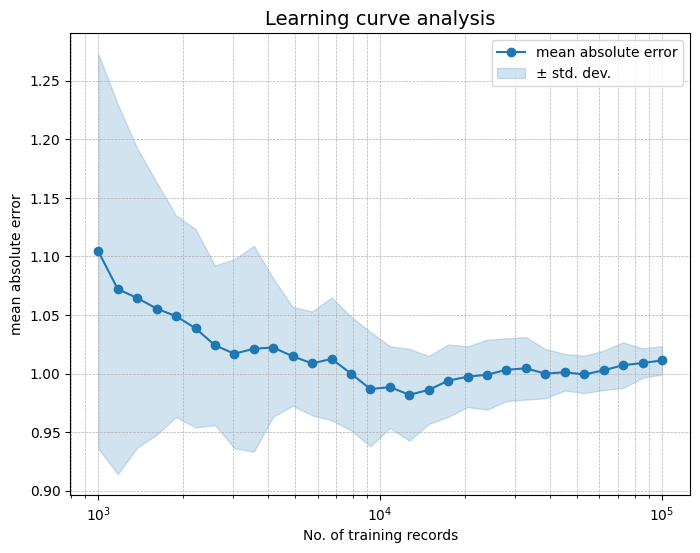

In [18]:
# Learning curve plot

reg_vis_obj.learning_curve_plot(
    np.logspace(3,5,30).astype(int),
    result_df.score_mean,
    result_df.score_std,
    log_sample=True,
    metric_label = 'mean absolute error'
    )

Failure analysis (regression)

In [19]:
# get worst examples on residual error
# ex_df,ex_info_df = evaluation.get_worst_examples(
#     model,test_data,
#     get_n=10,
#     target_col='Booking Value_fill_scaled',
#     problem_type='regression',
#     get_random_err=False,
#     random_state=0
# )

# test_shap_values,_ = evaluation.shap_analysis(
#     model,
#     shap.TreeExplainer,
#     train_df = shap.sample(train_data,nsamples=1000), # recommended number in documentation
#     test_df = shap.sample(test_data),
#     target_col = 'Booking Value_fill_scaled'
# )

# ex_shap_values,_ = evaluation.shap_analysis(
#     model,
#     shap.TreeExplainer,
#     train_df = shap.sample(train_data,nsamples=1000),  # recommended number in documentation
#     test_df = ex_df,
#     target_col = 'Booking Value_fill_scaled'
# )
# ex_info_df

In [20]:
# water fall plot

# true_val = ex_df['Booking Value_fill_scaled'].iloc[-1]
# reg_vis_obj.waterfall_plot(
#     ex_shap_values[-1],
#     title = f'True label value:{true_val}',
#     figsize=(7,4)
#     )

In [21]:
# beeswarm plot

# reg_vis_obj.beeswarm_plot(
#     test_shap_values,
#     figsize=(7,4)
#     )